In [2]:
# ============================================================
# CNN Development on Custom Dataset
# Dataset: Sign Language MNIST (24 classes used)
# Student Notebook: Submission-ready version
# ============================================================

In [3]:
# ============================================================
# 1. Install Required Packages
# ============================================================
!pip install kagglehub torchinfo -q

In [4]:
# ============================================================
# 2. Import Libraries
# ============================================================
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from torchinfo import summary
import kagglehub

In [5]:
# ============================================================
# 3. Project Explanation
# ============================================================
print("=" * 70)
print("PROJECT OVERVIEW")
print("=" * 70)
print("This notebook develops a custom CNN model for multi-class image")
print("classification using the Sign Language MNIST dataset.")
print()
print("Two CNN versions are compared:")
print("1. CNN without Batch Normalization and Dropout")
print("2. CNN with Batch Normalization and Dropout")
print()
print("The final model is selected based on validation accuracy,")
print("then evaluated on the test set using accuracy, precision,")
print("recall, F1-score, confusion matrix, and per-class analysis.")
print()

PROJECT OVERVIEW
This notebook develops a custom CNN model for multi-class image
classification using the Sign Language MNIST dataset.

Two CNN versions are compared:
1. CNN without Batch Normalization and Dropout
2. CNN with Batch Normalization and Dropout

The final model is selected based on validation accuracy,
then evaluated on the test set using accuracy, precision,
recall, F1-score, confusion matrix, and per-class analysis.



In [6]:
# ============================================================
# 4. Set Random Seed for Reproducibility
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [7]:
# ============================================================
# 5. Device Configuration
# ============================================================
# Rationale:
# GPU is used if available for faster training.
# Otherwise, CPU is used.
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

Device: cuda


In [8]:
# ============================================================
# 6. Download and Load Dataset
# ============================================================
path = kagglehub.dataset_download("datamunge/sign-language-mnist")
print("Path to dataset files:", path)

train_csv_path = os.path.join(path, "sign_mnist_train.csv")
test_csv_path = os.path.join(path, "sign_mnist_test.csv")

train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)

print("Original train shape:", train_df.shape)
print("Original test shape:", test_df.shape)

display(train_df.head())

Path to dataset files: /kaggle/input/datasets/datamunge/sign-language-mnist
Original train shape: (27455, 785)
Original test shape: (7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [9]:
# ============================================================
# 7. Dataset Exploration and Label Processing
# ============================================================
# The dataset labels are remapped into consecutive class indices
# because the original label values are not guaranteed to be continuous.

unique_labels = sorted(train_df['label'].unique())
label_map = {old_label: new_label for new_label, old_label in enumerate(unique_labels)}

train_df['label'] = train_df['label'].map(label_map)
test_df['label'] = test_df['label'].map(label_map)

# 24 classes used in this project
class_names = [
    'A','B','C','D','E','F','G','H','I',
    'K','L','M','N','O','P','Q','R','S',
    'T','U','V','W','X','Y'
]

num_classes = len(class_names)

print("Original labels:", unique_labels)
print("Mapped train labels:", sorted(train_df['label'].unique()))
print("Mapped test labels:", sorted(test_df['label'].unique()))
print("Number of classes used:", num_classes)

Original labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Mapped train labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
Mapped test labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np

In [10]:
# ============================================================
# 8. Hyperparameter Details and Rationale
# ============================================================
batch_size = 64
learning_rate = 1e-3
minimum_learning_rate = 1e-5
epochs = 20

print("\n" + "=" * 70)
print("HYPERPARAMETER DETAILS AND RATIONALE")
print("=" * 70)
print(f"Batch size: {batch_size}")
print("- Chosen to balance memory efficiency and training speed.")
print()
print(f"Initial learning rate: {learning_rate}")
print("- Chosen because Adam usually performs well with 1e-3 as a starting point.")
print()
print(f"Minimum learning rate: {minimum_learning_rate}")
print("- Used with cosine annealing to gradually reduce learning rate.")
print()
print(f"Epochs: {epochs}")
print("- 20 epochs provide enough training time while keeping runtime reasonable.")
print()
print("Optimizer: Adam")
print("- Selected because it converges faster and is widely used for CNN training.")
print()
print("Loss Function: CrossEntropyLoss")
print("- Used because this is a multi-class classification problem.")
print()


HYPERPARAMETER DETAILS AND RATIONALE
Batch size: 64
- Chosen to balance memory efficiency and training speed.

Initial learning rate: 0.001
- Chosen because Adam usually performs well with 1e-3 as a starting point.

Minimum learning rate: 1e-05
- Used with cosine annealing to gradually reduce learning rate.

Epochs: 20
- 20 epochs provide enough training time while keeping runtime reasonable.

Optimizer: Adam
- Selected because it converges faster and is widely used for CNN training.

Loss Function: CrossEntropyLoss
- Used because this is a multi-class classification problem.



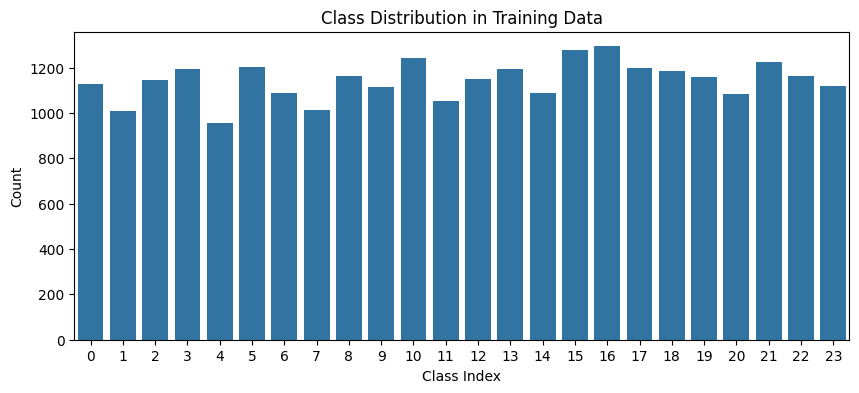

In [11]:
# ============================================================
# 9. Visualize Class Distribution
# ============================================================
plt.figure(figsize=(10, 4))
sns.countplot(x=train_df['label'])
plt.title("Class Distribution in Training Data")
plt.xlabel("Class Index")
plt.ylabel("Count")
plt.show()

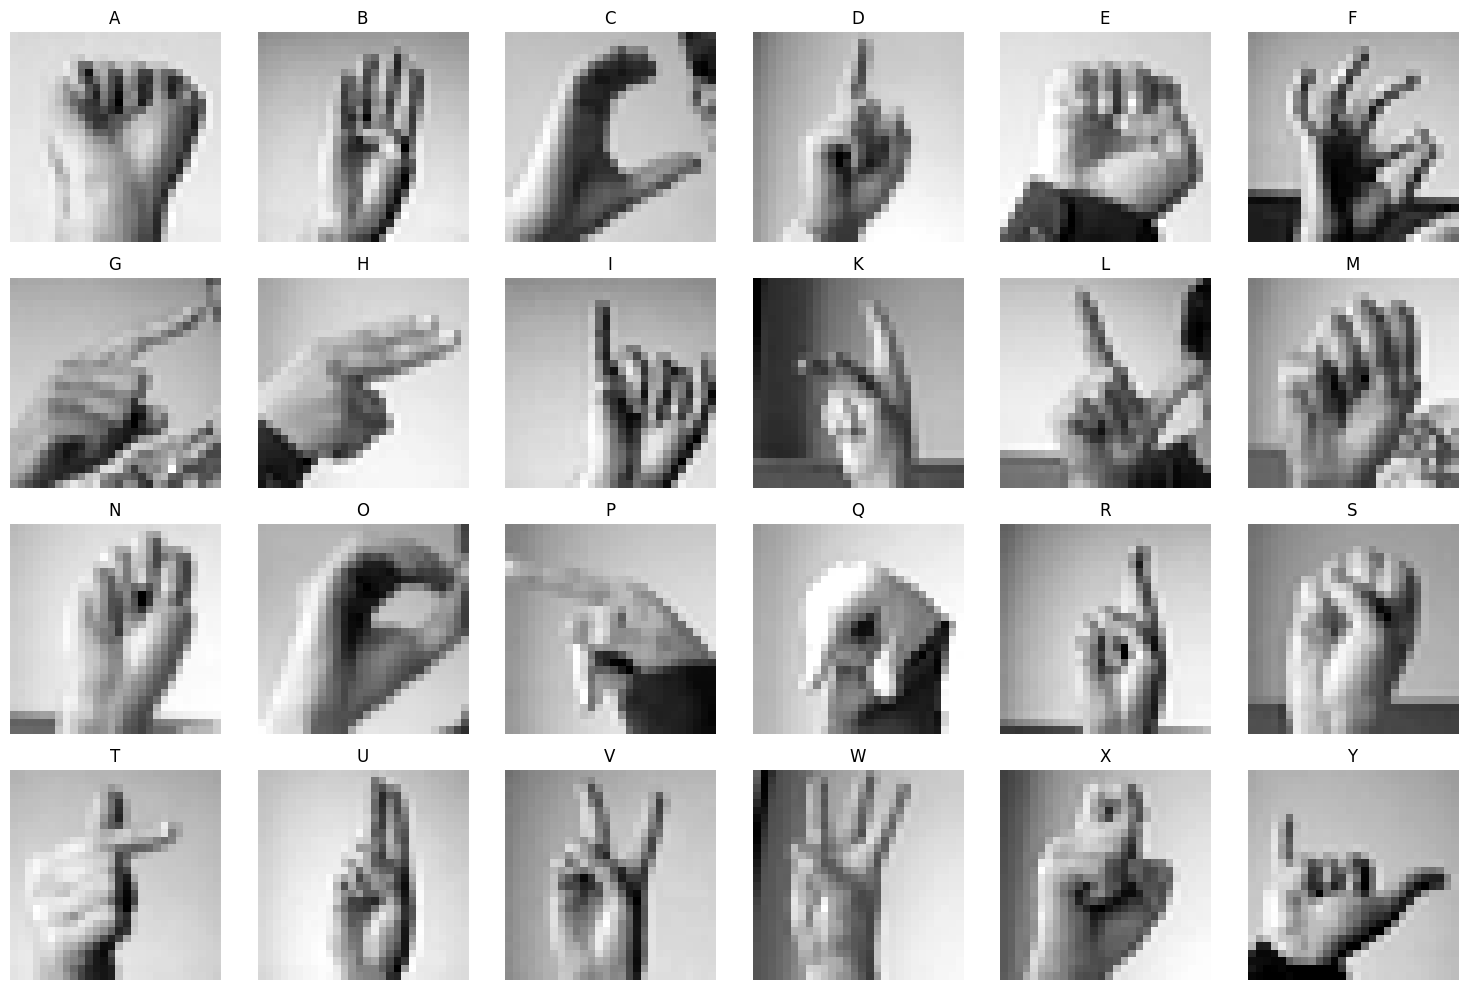

In [12]:
# ============================================================
# 10. Visualize One Sample from Each Class
# ============================================================
plt.figure(figsize=(15, 10))

mapped_labels = sorted(train_df['label'].unique())

for plot_idx, label_value in enumerate(mapped_labels):
    sample = train_df[train_df['label'] == label_value].iloc[0]
    image = sample.iloc[1:].values.astype(np.float32).reshape(28, 28)

    plt.subplot(4, 6, plot_idx + 1)
    plt.imshow(image, cmap='gray')
    plt.title(class_names[label_value])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# 11. Train-Validation Split
# ============================================================
# Rationale:
# Stratified splitting keeps class distribution balanced in both sets.
train_data_df, val_data_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['label']
)

print("Train split shape:", train_data_df.shape)
print("Validation split shape:", val_data_df.shape)
print("Test shape:", test_df.shape)

Train split shape: (21964, 785)
Validation split shape: (5491, 785)
Test shape: (7172, 785)


In [14]:
# ============================================================
# 12. Custom PyTorch Dataset
# ============================================================
class SignLanguageDataset(Dataset):
    def __init__(self, dataframe):
        self.dataframe = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        label = int(row['label'])
        image = row.iloc[1:].values.astype(np.float32).reshape(28, 28) / 255.0
        image = np.expand_dims(image, axis=0)  # shape: (1, 28, 28)

        image = torch.tensor(image, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.long)

        return image, label

In [15]:
# ============================================================
# 13. Create Datasets and DataLoaders
# ============================================================
train_dataset = SignLanguageDataset(train_data_df)
val_dataset = SignLanguageDataset(val_data_df)
test_dataset = SignLanguageDataset(test_df)

# Note:
# num_workers=0 is safer in Kaggle and avoids worker-related issues.
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 344
Validation batches: 86
Test batches: 113


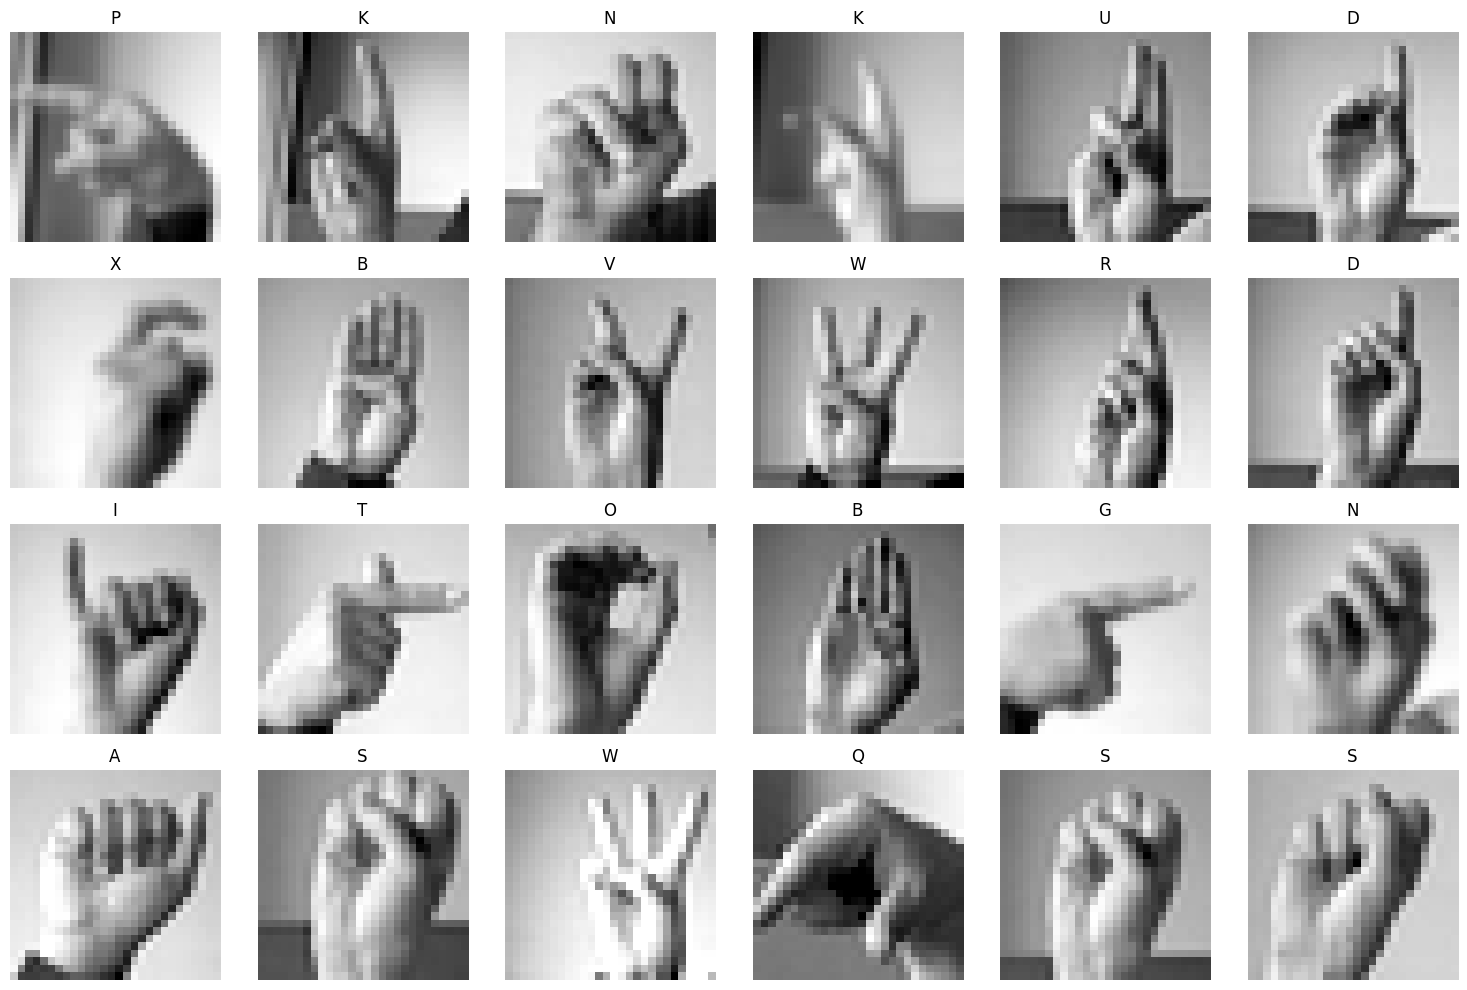

In [16]:
# ============================================================
# 14. Show Sample Batch Images
# ============================================================
images, labels = next(iter(train_loader))

plt.figure(figsize=(15, 10))
for i in range(min(num_classes, len(images))):
    plt.subplot(4, 6, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(class_names[labels[i].item()])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# 15. Define CNN Model Without BatchNorm and Dropout
# ============================================================
class CNNWithoutBNDropout(nn.Module):
    def __init__(self, num_classes=24):
        super(CNNWithoutBNDropout, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 28 -> 14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 14 -> 7

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [18]:
# ============================================================
# 16. Define CNN Model With BatchNorm and Dropout
# ============================================================
class CNNWithBNDropout(nn.Module):
    def __init__(self, num_classes=24):
        super(CNNWithBNDropout, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.10),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.20),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.30)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.40),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [19]:
# ============================================================
# 17. Detailed Model Summary
# ============================================================
print("=" * 70)
print("MODEL SUMMARY: CNN WITH BATCH NORMALIZATION AND DROPOUT")
print("=" * 70)
model_temp = CNNWithBNDropout(num_classes=num_classes).to(device)
summary(model_temp, input_size=(32, 1, 28, 28))

MODEL SUMMARY: CNN WITH BATCH NORMALIZATION AND DROPOUT


Layer (type:depth-idx)                   Output Shape              Param #
CNNWithBNDropout                         [32, 24]                  --
├─Sequential: 1-1                        [32, 128, 7, 7]           --
│    └─Conv2d: 2-1                       [32, 32, 28, 28]          320
│    └─BatchNorm2d: 2-2                  [32, 32, 28, 28]          64
│    └─ReLU: 2-3                         [32, 32, 28, 28]          --
│    └─Conv2d: 2-4                       [32, 32, 28, 28]          9,248
│    └─BatchNorm2d: 2-5                  [32, 32, 28, 28]          64
│    └─ReLU: 2-6                         [32, 32, 28, 28]          --
│    └─MaxPool2d: 2-7                    [32, 32, 14, 14]          --
│    └─Dropout2d: 2-8                    [32, 32, 14, 14]          --
│    └─Conv2d: 2-9                       [32, 64, 14, 14]          18,496
│    └─BatchNorm2d: 2-10                 [32, 64, 14, 14]          128
│    └─ReLU: 2-11                        [32, 64, 14, 14]          --
│    └

In [20]:
# ============================================================
# 18. Training Function for One Epoch
# ============================================================
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(loader)
    train_acc = correct / total

    return train_loss, train_acc

In [21]:
# ============================================================
# 19. Validation Function
# ============================================================
def validate_epoch(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = total_loss / len(loader)
    val_acc = correct / total

    return val_loss, val_acc

In [22]:
# ============================================================
# 20. Full Training Function
# ============================================================
def run_training(model, train_loader, val_loader, epochs, learning_rate, minimum_learning_rate, device):
    model = model.to(device)

    optimizer = Adam(model.parameters(), lr=learning_rate)
    scheduler = CosineAnnealingLR(
        optimizer,
        T_max=epochs,
        eta_min=minimum_learning_rate
    )
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(epochs):
        print("-" * 60)
        print(f"Epoch {epoch + 1}/{epochs} | Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")

        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)

        scheduler.step()

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)

    history = {
        "train_losses": train_losses,
        "train_accuracies": train_accuracies,
        "val_losses": val_losses,
        "val_accuracies": val_accuracies,
        "best_val_acc": best_val_acc
    }

    return model, history

In [23]:
# ============================================================
# 21. Train Model Without BatchNorm and Dropout
# ============================================================
print("\n" + "=" * 70)
print("TRAINING MODEL 1: CNN WITHOUT BATCH NORMALIZATION / DROPOUT")
print("=" * 70)

model1 = CNNWithoutBNDropout(num_classes=num_classes)

model1, history1 = run_training(
    model=model1,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=epochs,
    learning_rate=learning_rate,
    minimum_learning_rate=minimum_learning_rate,
    device=device
)


TRAINING MODEL 1: CNN WITHOUT BATCH NORMALIZATION / DROPOUT
------------------------------------------------------------
Epoch 1/20 | Learning Rate: 0.001000
Train Loss: 1.7027 | Train Accuracy: 0.4700
Val Loss:   0.2695 | Val Accuracy:   0.9078
------------------------------------------------------------
Epoch 2/20 | Learning Rate: 0.000994
Train Loss: 0.1314 | Train Accuracy: 0.9549
Val Loss:   0.0317 | Val Accuracy:   0.9896
------------------------------------------------------------
Epoch 3/20 | Learning Rate: 0.000976
Train Loss: 0.0347 | Train Accuracy: 0.9889
Val Loss:   0.0130 | Val Accuracy:   0.9975
------------------------------------------------------------
Epoch 4/20 | Learning Rate: 0.000946
Train Loss: 0.0205 | Train Accuracy: 0.9941
Val Loss:   0.0009 | Val Accuracy:   1.0000
------------------------------------------------------------
Epoch 5/20 | Learning Rate: 0.000905
Train Loss: 0.0032 | Train Accuracy: 0.9994
Val Loss:   0.0129 | Val Accuracy:   0.9960
---------

In [24]:
# ============================================================
# 22. Train Model With BatchNorm and Dropout
# ============================================================
print("\n" + "=" * 70)
print("TRAINING MODEL 2: CNN WITH BATCH NORMALIZATION / DROPOUT")
print("=" * 70)

model2 = CNNWithBNDropout(num_classes=num_classes)

model2, history2 = run_training(
    model=model2,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=epochs,
    learning_rate=learning_rate,
    minimum_learning_rate=minimum_learning_rate,
    device=device
)


TRAINING MODEL 2: CNN WITH BATCH NORMALIZATION / DROPOUT
------------------------------------------------------------
Epoch 1/20 | Learning Rate: 0.001000
Train Loss: 0.7686 | Train Accuracy: 0.7994
Val Loss:   0.0244 | Val Accuracy:   0.9993
------------------------------------------------------------
Epoch 2/20 | Learning Rate: 0.000994
Train Loss: 0.0411 | Train Accuracy: 0.9962
Val Loss:   0.0024 | Val Accuracy:   1.0000
------------------------------------------------------------
Epoch 3/20 | Learning Rate: 0.000976
Train Loss: 0.0137 | Train Accuracy: 0.9993
Val Loss:   0.0009 | Val Accuracy:   1.0000
------------------------------------------------------------
Epoch 4/20 | Learning Rate: 0.000946
Train Loss: 0.0076 | Train Accuracy: 0.9997
Val Loss:   0.0003 | Val Accuracy:   1.0000
------------------------------------------------------------
Epoch 5/20 | Learning Rate: 0.000905
Train Loss: 0.0131 | Train Accuracy: 0.9980
Val Loss:   0.0012 | Val Accuracy:   1.0000
------------

In [25]:
# ============================================================
# 23. Compare Validation Performance and Select Final Model
# ============================================================
print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)
print("Best Validation Accuracy - Without BN/Dropout:", history1["best_val_acc"])
print("Best Validation Accuracy - With BN/Dropout:", history2["best_val_acc"])

if history2["best_val_acc"] >= history1["best_val_acc"]:
    final_model = model2
    final_history = history2
    final_model_name = "CNNWithBNDropout"
else:
    final_model = model1
    final_history = history1
    final_model_name = "CNNWithoutBNDropout"

print("Selected Final Model:", final_model_name)


MODEL COMPARISON
Best Validation Accuracy - Without BN/Dropout: 1.0
Best Validation Accuracy - With BN/Dropout: 1.0
Selected Final Model: CNNWithBNDropout


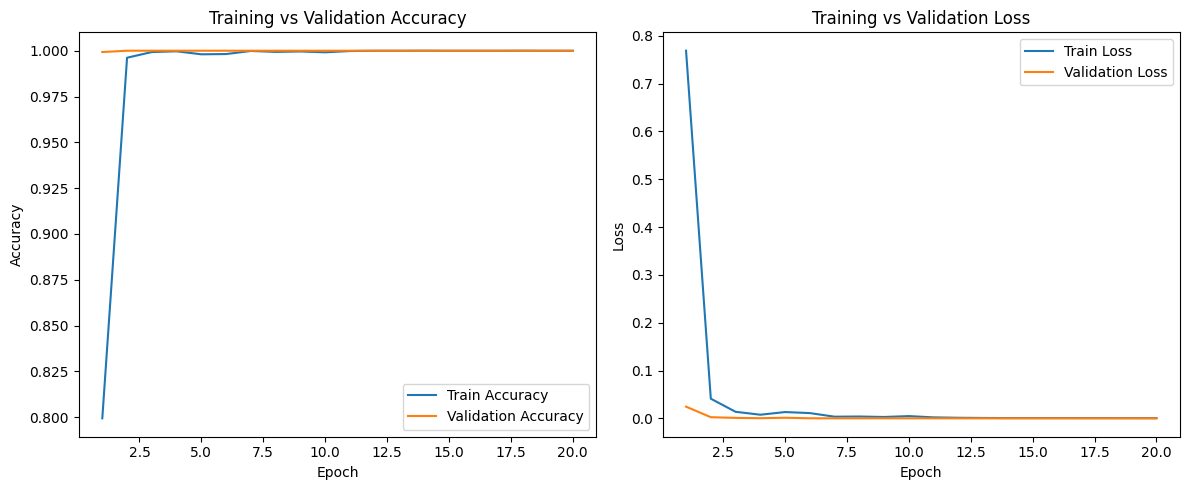

In [26]:
# ============================================================
# 24. Plot Training and Validation Curves
# ============================================================
epochs_range = range(1, len(final_history["train_accuracies"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, final_history["train_accuracies"], label='Train Accuracy')
plt.plot(epochs_range, final_history["val_accuracies"], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, final_history["train_losses"], label='Train Loss')
plt.plot(epochs_range, final_history["val_losses"], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# 25. Test Evaluation Function
# ============================================================
def evaluate_on_test(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = total_loss / len(loader)
    test_acc = correct / total

    return test_loss, test_acc, all_labels, all_preds

In [28]:
# ============================================================
# 26. Evaluate Final Model on Test Set
# ============================================================
criterion = nn.CrossEntropyLoss()

test_loss, test_acc, all_labels, all_preds = evaluate_on_test(
    model=final_model,
    loader=test_loader,
    criterion=criterion,
    device=device
)

print("\n" + "=" * 70)
print("TEST SET EVALUATION")
print("=" * 70)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)


TEST SET EVALUATION
Test Loss: 0.024858709449459494
Test Accuracy: 0.9949804796430564


In [29]:
# ============================================================
# 27. Classification Report
# ============================================================
print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

report_text = classification_report(all_labels, all_preds, target_names=class_names)
print(report_text)

report_dict = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    output_dict=True
)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           A       0.99      1.00      1.00       331
           B       1.00      1.00      1.00       432
           C       1.00      1.00      1.00       310
           D       1.00      1.00      1.00       245
           E       1.00      0.98      0.99       498
           F       1.00      1.00      1.00       247
           G       1.00      0.95      0.97       348
           H       1.00      1.00      1.00       436
           I       1.00      1.00      1.00       288
           K       1.00      1.00      1.00       331
           L       1.00      1.00      1.00       209
           M       1.00      1.00      1.00       394
           N       1.00      0.99      1.00       291
           O       1.00      1.00      1.00       246
           P       1.00      1.00      1.00       347
           Q       1.00      1.00      1.00       164
           R       1.00      0.99      1.00       144
    

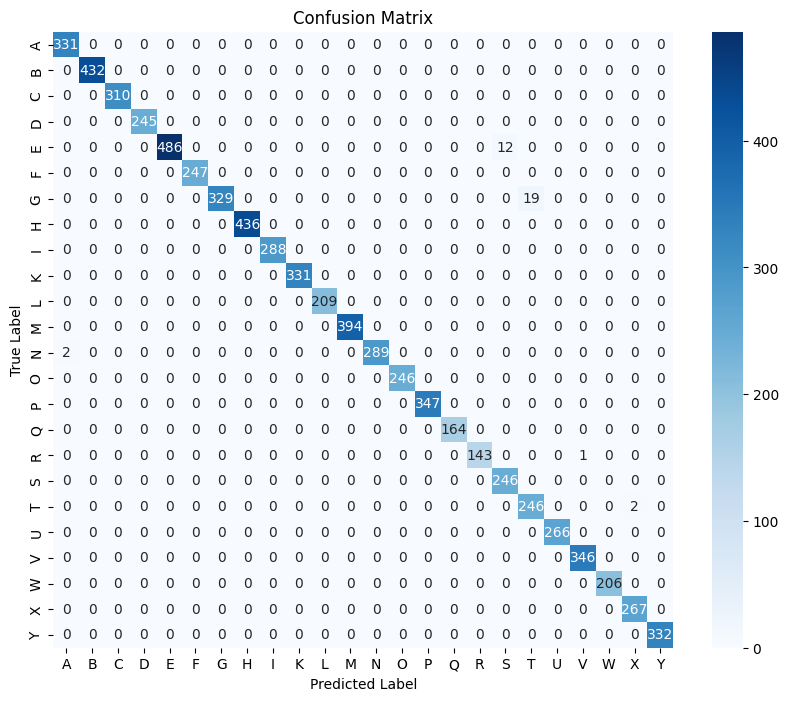

In [30]:
# ============================================================
# 28. Confusion Matrix Visualization
# ============================================================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [31]:
# ============================================================
# 29. Per-Class Performance Analysis
# ============================================================
class_f1_scores = {}

for class_name in class_names:
    class_f1_scores[class_name] = report_dict[class_name]['f1-score']

best_class = max(class_f1_scores, key=class_f1_scores.get)
worst_class = min(class_f1_scores, key=class_f1_scores.get)

print("\n" + "=" * 70)
print("PER-CLASS PERFORMANCE ANALYSIS")
print("=" * 70)
print("Best Performing Class:", best_class, "| F1-score:", class_f1_scores[best_class])
print("Worst Performing Class:", worst_class, "| F1-score:", class_f1_scores[worst_class])

print("\nAll Class F1-Scores:")
for class_name, score in class_f1_scores.items():
    print(f"{class_name}: {score:.4f}")


PER-CLASS PERFORMANCE ANALYSIS
Best Performing Class: B | F1-score: 1.0
Worst Performing Class: T | F1-score: 0.9590643274853801

All Class F1-Scores:
A: 0.9970
B: 1.0000
C: 1.0000
D: 1.0000
E: 0.9878
F: 1.0000
G: 0.9719
H: 1.0000
I: 1.0000
K: 1.0000
L: 1.0000
M: 1.0000
N: 0.9966
O: 1.0000
P: 1.0000
Q: 1.0000
R: 0.9965
S: 0.9762
T: 0.9591
U: 1.0000
V: 0.9986
W: 1.0000
X: 0.9963
Y: 1.0000


In [32]:
# ============================================================
# 30. Save Trained Model Weights
# ============================================================
model_save_path = "best_sign_language_cnn.pth"
torch.save(final_model.state_dict(), model_save_path)
print(f"Trained model weights saved as: {model_save_path}")

Trained model weights saved as: best_sign_language_cnn.pth


In [33]:
# ============================================================
# 31. Final Analysis and Discussion
# ============================================================
print("\n" + "=" * 70)
print("ANALYSIS AND DISCUSSION")
print("=" * 70)
print("1. Two custom CNN architectures were tested.")
print("2. The model with the higher validation accuracy was selected as final.")
print("3. Batch normalization and dropout were included to study regularization.")
print("4. The final model was evaluated using test accuracy, precision, recall, and F1-score.")
print("5. A confusion matrix was generated to visualize prediction quality.")
print("6. Best and worst performing classes were identified using per-class F1-score.")
print()


ANALYSIS AND DISCUSSION
1. Two custom CNN architectures were tested.
2. The model with the higher validation accuracy was selected as final.
3. Batch normalization and dropout were included to study regularization.
4. The final model was evaluated using test accuracy, precision, recall, and F1-score.
5. A confusion matrix was generated to visualize prediction quality.
6. Best and worst performing classes were identified using per-class F1-score.



In [34]:
# ============================================================
# 32. Conclusion and Future Work
# ============================================================
print("=" * 70)
print("CONCLUSION AND FUTURE WORK")
print("=" * 70)
print("Conclusion:")
print("This project successfully developed and evaluated a CNN for multi-class")
print("sign language image classification. The comparison between two CNN")
print("variants showed the impact of batch normalization and dropout on")
print("validation performance.")
print()
print("Future Work:")
print("- Use data augmentation for better generalization")
print("- Try deeper CNN architectures")
print("- Tune hyperparameters further")
print("- Use early stopping for more efficient training")
print()
print("Notebook completed successfully.")

CONCLUSION AND FUTURE WORK
Conclusion:
This project successfully developed and evaluated a CNN for multi-class
sign language image classification. The comparison between two CNN
variants showed the impact of batch normalization and dropout on
validation performance.

Future Work:
- Use data augmentation for better generalization
- Try deeper CNN architectures
- Tune hyperparameters further
- Use early stopping for more efficient training

Notebook completed successfully.
